In [1]:
import pandas as pd 
import numpy as np 

import seaborn as sns
from types import MappingProxyType as rodict

import matplotlib
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
matplotlib.rcParams['font.family'] = 'serif'  # Or 'DejaVu Serif', 'Times New Roman'
matplotlib.rcParams['pdf.fonttype'] = 42  # For text-editable fonts in PDFs
matplotlib.rcParams['ps.fonttype'] = 42 
from scipy.stats import pearsonr, kendalltau
from matplotlib import ticker

## Preparing input data 

In [2]:
print('Preparing data...')

FREEZE = False
FREEZE_SUFFIX = '_frozen' if FREEZE else ''

INPUT_FILE = f"../inputs/transf_scores{FREEZE_SUFFIX}.csv"
# Read the input data
print(f"Reading input file path: {INPUT_FILE}")
df_full = pd.read_csv(INPUT_FILE)


# ... filters the data by datasets and scorers
ALL_MODELS = df_full['model'].unique().tolist()
ALL_SCORERS = df_full['transf_metric'].unique().tolist()
ALL_DBS =  df_full['dataset'].unique().tolist()

Preparing data...
Reading input file path: ../inputs/transf_scores.csv


In [3]:
df_full.tail(30)

,dataset,model,test_score,classes,transf_metric,transf_score
1510,skin_splits,densenet121,0.869602,2,etran_energy_score,1.214145
1511,skin_splits,densenet161,0.888792,2,etran_energy_score,1.868118
1512,skin_splits,densenet169,0.882190,2,etran_energy_score,1.438128
1513,skin_splits,efficientnet_b0,0.879774,2,etran_energy_score,0.861564
1514,skin_splits,mobilenetv2_050,0.766614,2,etran_energy_score,0.252736
1515,skin_splits,mobilenetv2_100,0.862750,2,etran_energy_score,0.903955
1516,skin_splits,resnet18,0.877213,2,etran_energy_score,0.918501
1517,skin_splits,resnet34,0.871371,2,etran_energy_score,1.272059
1518,skin_splits,resnet50,0.837430,2,etran_energy_score,1.428716
1519,skin_splits,vit_small_patch16_224,0.887396,2,etran_energy_score,1.825324


### Define variables

In [4]:
DATASET_ORDER = ['caltech101',
                'sun397',
                'voc2007',
                'flowers102',
                'oxfordpets',
                'aircraft',
                'dtd',
                'stanfordcars',
                'brain_tumor_kaggle',
                'breakhis',
                'skin_splits']


MODEL_TO_NAMES = rodict({
    'densenet121':           'DenseNet-121',
    'densenet161':           'DenseNet-161',
    'densenet169':           'DenseNet-169',
    'mobilenetv2_050':       'MobileNet-v2-050',
    'mobilenetv2_100':       'MobileNet-v2-100',
    'resnet18':              'ResNet-18',
    'resnet34':              'ResNet-34',
    'resnet50':              'ResNet-50',
    'efficientnet_b0':       'EfficientNet-B0',
    'vit_small_patch16_224': 'ViT-small-16-224',
})

TRANSF_METRICS_TO_NAMES = rodict({
    'imagenet':           'ImageNet',
    'ncti_score':         'NCTI',
    'etran_energy_score': 'ETran',
    'pactran_score':      'PACTran',
    'gbc_score':          'GBC',
    'parc_score':         'PARC',
    'nleep_score':        'NLEEP',
    'leep_score':         'LEEP',
    'logme_score':        'LogME',
    'tmi_score':          'TMI',
    'nce_score':          'NCE',
    'sfda_score':         'SFDA',
    'hscore_score':       'H-Score',
    'reg_hscore_score':   'R.H-Score',
})


DATASET_TO_LEGEND = rodict({
    'sun397':             'SUN397',
    'aircraft':           'Aircraft',
    'caltech101':         'Cal-101',
    'oxfordpets':         'Ox.Pets',
    'flowers102':         'Ox.Flowers',
    'dtd':                'DTD',
    'stanfordcars':       'Stan.Cars',
    'voc2007':            'VOC 2007',
    'brain_tumor_kaggle': 'BrainTumor',
    'breakhis':           'BreakHis',
    'skin_splits':        'ISIC 2019',
})

SCORER_ORDER = ["ncti_score",        
                "etran_energy_score",
                "pactran_score",     
                "gbc_score",         
                "parc_score",        
                "nleep_score",       
                "leep_score",        
                "logme_score",       
                "tmi_score",         
                "nce_score",         
                "sfda_score",        
                "hscore_score",      
                "reg_hscore_score",  
                ]

# SCORER_ORDER = ["ncti_score",        
#                 "etran_energy_score",
#                 "pactran_score",     
#                 "gbc_score",         
#                     ]


## Plotting correlogram 

In [5]:
# # Iterate over all scorers 

# target_field = 'transf_score'
# # A layout of 13x13 subplots
# fig, axes = plt.subplots(len(SCORER_ORDER), 
#                          len(SCORER_ORDER), 
#                          figsize = (20, 20), 
#                         #  sharex="col", 
#                          dpi=200,)

# # Adjust spacing to be tight like the R plot
# fig.subplots_adjust(hspace=0.0, wspace=0.0)

# for i, scorer_name_first in enumerate(SCORER_ORDER):
#     for j, scorer_name_second in enumerate(SCORER_ORDER):
        
#         ax = axes[i, j]

#         data_col = df_full[(df_full.transf_metric == scorer_name_second)][target_field]        
#         data_row = df_full[(df_full.transf_metric == scorer_name_first)][target_field]

#         if len(data_col) != len(data_row):
#             print("Lascou")
#         x = data_row.values
#         y = data_col.values
#         r, p = kendalltau(x, y)
#         r = int(r * 100)
#         # corr_color = 'darkorange' if r <= 0 else 'black'
#         corr_color = "#F27F38" if r <= 0 else "black"

#         # If this is the lower-triangule, add a scatterlpot.
#         if i > j:
#             ax.scatter(data_col, data_row, 
#                        alpha=0.8, color=corr_color, 
#                        s=20)    

#         # If this is the main diagonal, add histograms
#         if i == j:

#             sns.histplot(data_row, ax=ax, 
#                          stat="density", bins=10,
#                          color="#D3D3D3", edgecolor='black', # Light gray fill, black edge
#                          kde=True, 
#                          line_kws={'color': 'red', 'linewidth': 2}, # Red KDE line
#                          ) 
            
#             # # Add variable name inside the plot
#             # ax.text(0.5, 0.9, scorer_name_first, transform=ax.transAxes, 
#             #         ha='center', va='center', fontsize=22)


#         # If on the upper triangle
#         if i < j:
#             ax.axis('off')  # Turn off axis completely


#             # --- Hyperparameters for the visualization ---
#             # Threshold to decide whether to draw a sphere or just text
#             # Font size for weak correlations (text only)
#             weak_corr_fontsize = 22

#              # --- Main Logic ---
#             if p <= 1e-3:

#                 # Draw the circle
#                 circle = mpatches.Circle((0.5, 0.5), 0.35, 
#                                         transform=ax.transAxes,
#                                         facecolor=corr_color, 
#                                         edgecolor=corr_color,
#                                         linewidth=2,
#                                         linestyle='--')
#                 ax.add_patch(circle)
    
                
#                 ax.text(0.5, 0.5, str(abs(r)),
#                         ha='center', va='center',
#                         transform=ax.transAxes,
#                         fontsize=weak_corr_fontsize,
#                         color='white')
#             else:
#                 ax.text(0.5, 0.5, str(abs(r)),
#                         ha='center', va='center',
#                         transform=ax.transAxes,
#                         fontsize=weak_corr_fontsize+7,
#                         color=corr_color)


#         ax.set_xticklabels([])
#         ax.set_yticklabels([])
#         ax.set_xlabel('')
#         ax.set_ylabel('')
        
#         # ax.tick_params(axis='both', which='major', labelsize=12)


# for i, scorer_name in enumerate(SCORER_ORDER):
#     axes[i, 0].set_ylabel(TRANSF_METRICS_TO_NAMES[scorer_name], 
#                           fontsize=16)
#     axes[-1, i].set_xlabel(TRANSF_METRICS_TO_NAMES[scorer_name], 
#                            fontsize=16)

# # fig.tight_layout()
# fig.show()
# fig.savefig(f'../outputs/corr_per_scorer{FREEZE_SUFFIX}.pdf', 
#             pad_inches=0,
#             bbox_inches='tight')

In [6]:
# # Iterate over all scorers 

# target_field = 'transf_score'
# # A layout of 13x13 subplots
# fig, axes = plt.subplots(len(SCORER_ORDER), 
#                          len(SCORER_ORDER), 
#                          figsize = (20, 20), 
#                         #  sharex="col", 
#                          dpi=200,)

# # Adjust spacing to be tight like the R plot
# fig.subplots_adjust(hspace=0.0, wspace=0.0)

# for i, scorer_name_first in enumerate(SCORER_ORDER):
#     for j, scorer_name_second in enumerate(SCORER_ORDER):
        
#         ax = axes[i, j]

#         data_col = df_full[(df_full.transf_metric == scorer_name_second)][target_field]        
#         data_row = df_full[(df_full.transf_metric == scorer_name_first)][target_field]

#         if len(data_col) != len(data_row):
#             print("Lascou")
#         x = data_row.values
#         y = data_col.values
#         r, p = kendalltau(x, y)
#         r = int(r * 100)
#         # corr_color = "#F27F38" if r <= 0 else "black" # old 
#         corr_color = "#000000" if r <= 0 else "#40A4F1"

#         # If this is the lower-triangule, add a scatterlpot.
#         if i > j:
#             ax.scatter(data_col, data_row, 
#                        alpha=0.8, color=corr_color, 
#                        s=20)    


#         # If on the upper triangle
#         if i < j:
#             ax.axis('off')  # Turn off axis completely


#             # --- Hyperparameters for the visualization ---
#             # Threshold to decide whether to draw a sphere or just text
#             # Font size for weak correlations (text only)
#             weak_corr_fontsize = 22

#              # --- Main Logic ---
#             if p <= 1e-3:

#                 # Draw the circle
#                 circle = mpatches.Circle((0.5, 0.5), 
#                                          radius=0.25, 
#                                         transform=ax.transAxes,
#                                         facecolor=corr_color, 
#                                         edgecolor=corr_color,
#                                         linewidth=2,
#                                         linestyle='--')
#                 ax.add_patch(circle)
    
                
#                 ax.text(0.5, 0.5, str(abs(r)),
#                         ha='center', va='center',
#                         transform=ax.transAxes,
#                         fontsize=weak_corr_fontsize,
#                         color='white')
#             else:
#                 ax.text(0.5, 0.5, str(abs(r)),
#                         ha='center', va='center',
#                         transform=ax.transAxes,
#                         fontsize=weak_corr_fontsize+7,
#                         color=corr_color)


#         ax.set_xticklabels([])
#         ax.set_yticklabels([])
#         ax.set_xlabel('')
#         ax.set_ylabel('')

#         if i == j:
#             ax.axis('off')
        
#         # ax.tick_params(axis='both', which='major', labelsize=12)


# for i, scorer_name in enumerate(SCORER_ORDER):
#     axes[i, 0].set_ylabel(TRANSF_METRICS_TO_NAMES[scorer_name], 
#                           fontsize=16)
#     axes[-1, i].set_xlabel(TRANSF_METRICS_TO_NAMES[scorer_name], 
#                            fontsize=16)

# # fig.tight_layout()
# fig.show()
# fig.savefig(f'../outputs/corr_per_scorer{FREEZE_SUFFIX}.pdf', 
#             pad_inches=0,
#             bbox_inches='tight')

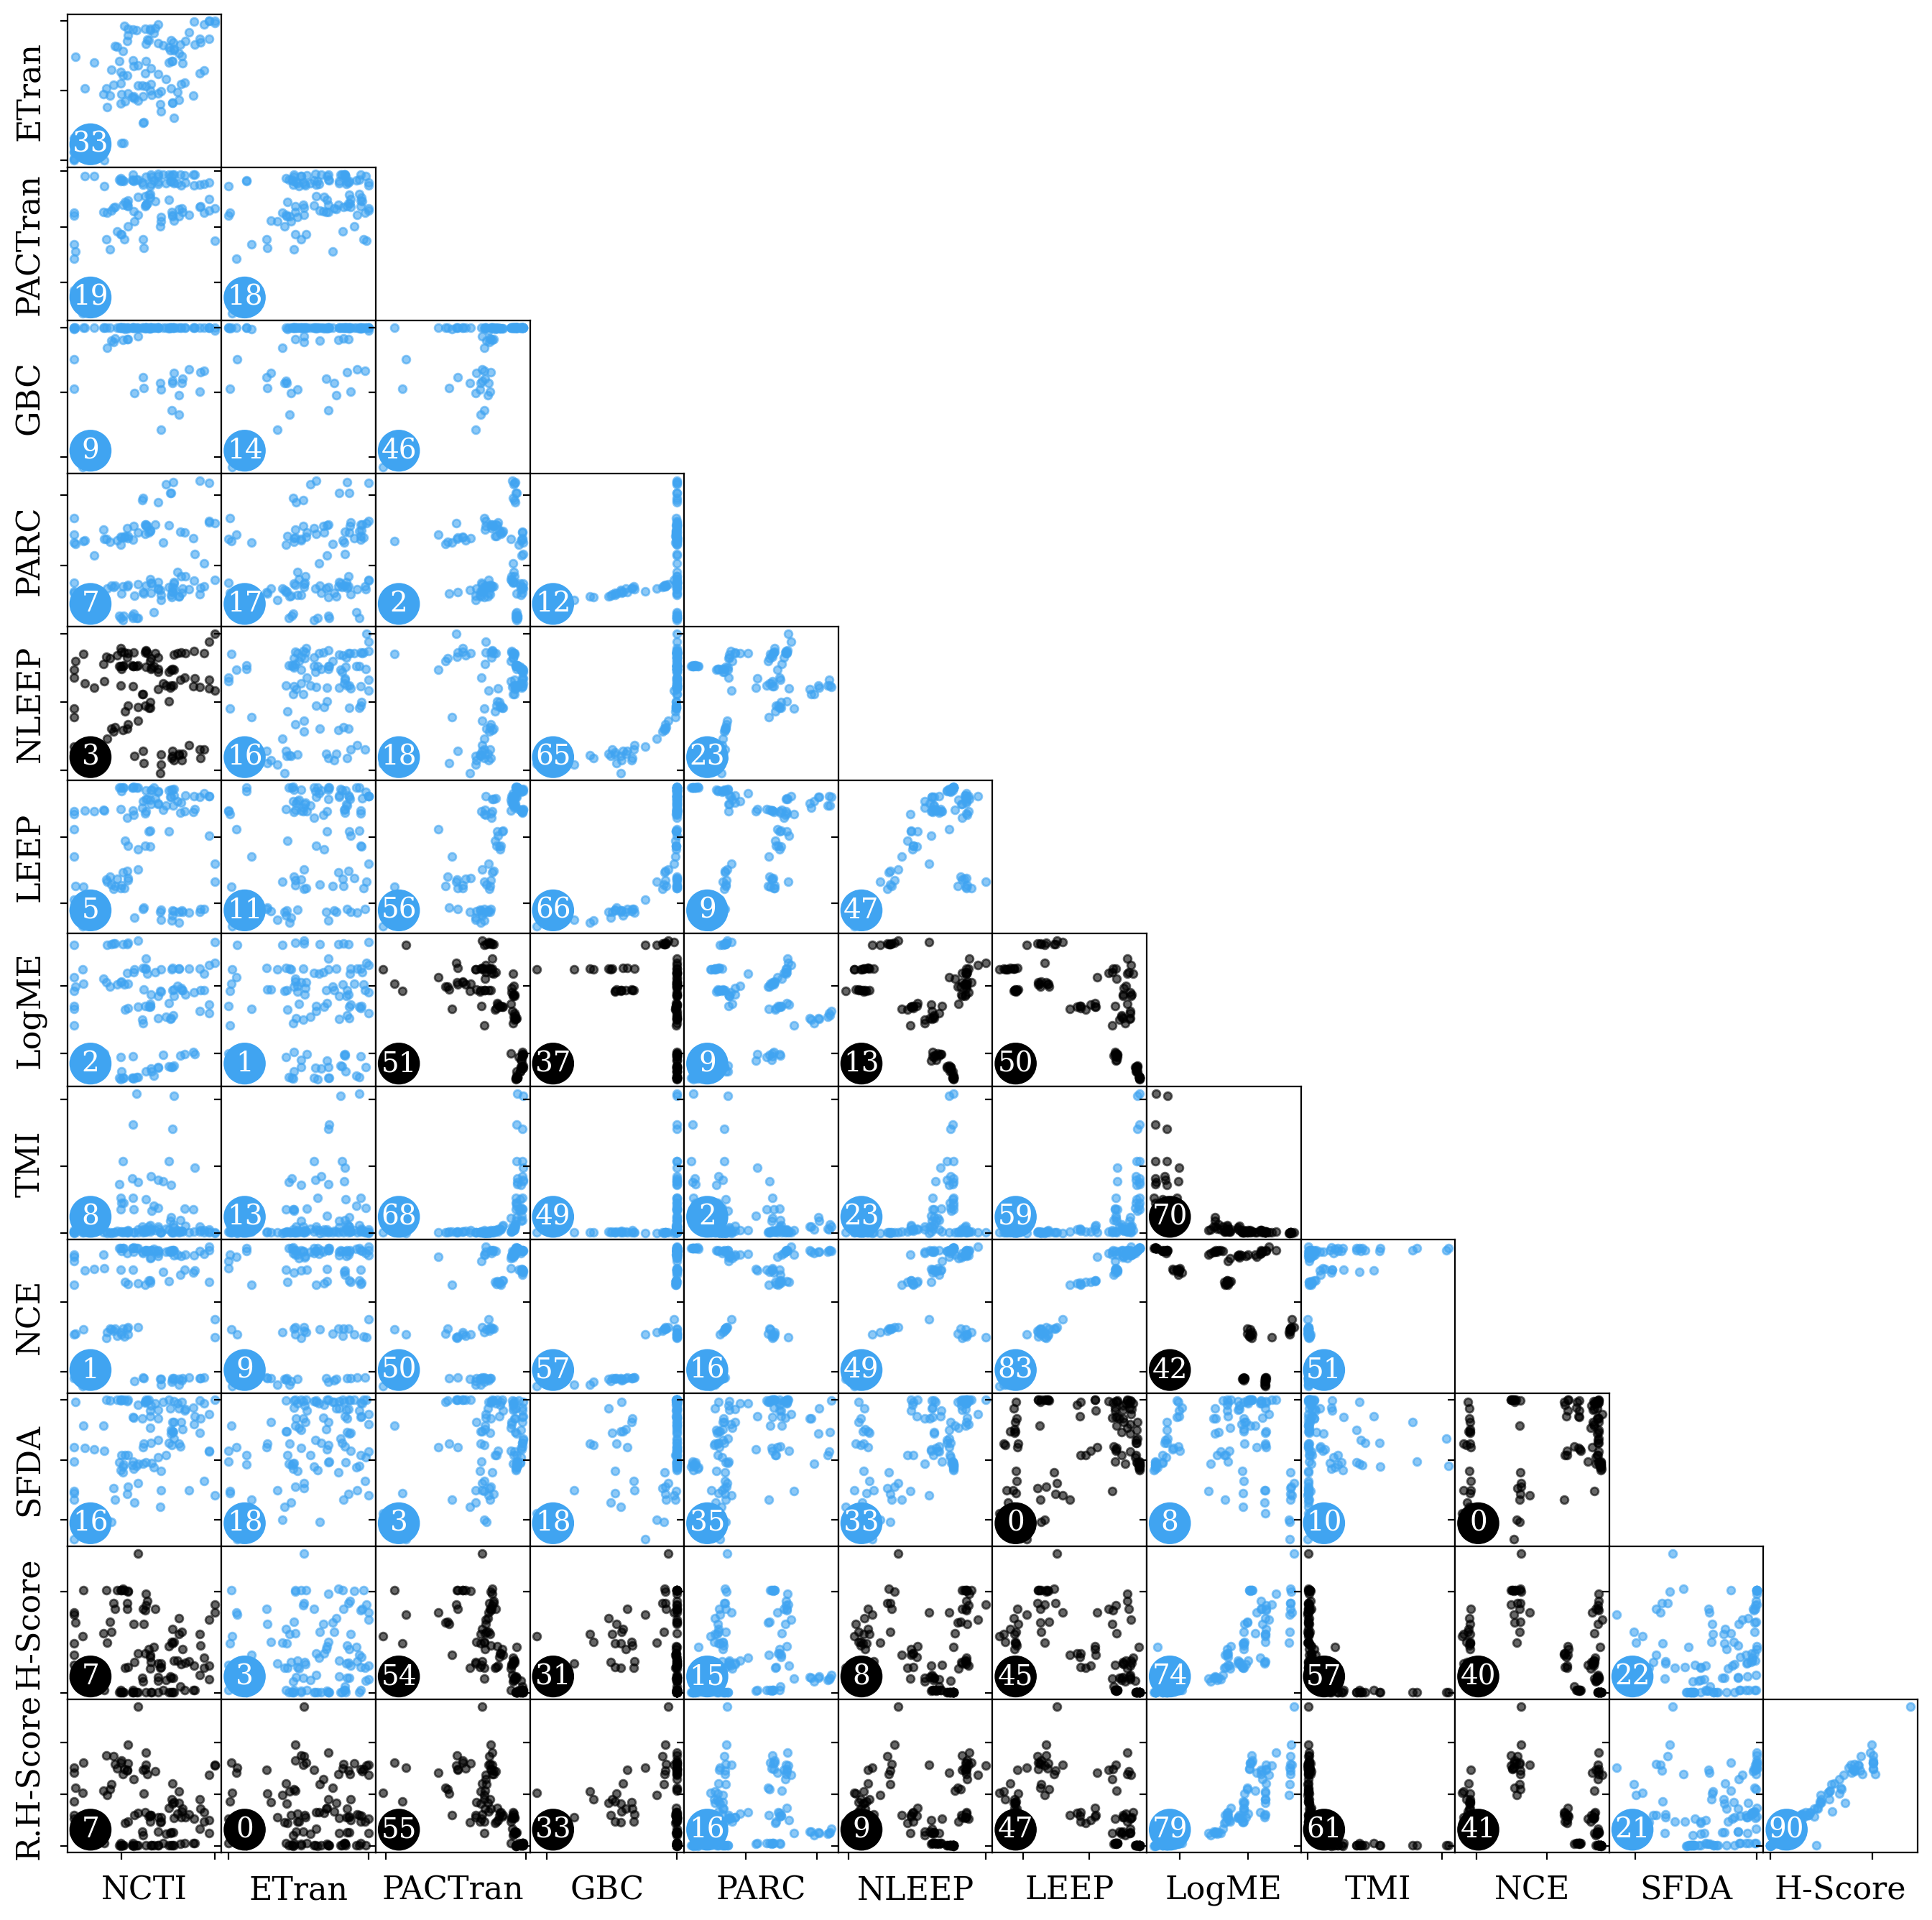

In [15]:
target_field = 'transf_score'
# A layout of 13x13 subplots
fig, axes = plt.subplots(len(SCORER_ORDER), 
                         len(SCORER_ORDER), 
                         figsize = (18, 18), 
                         dpi=200)

# Adjust spacing to be tight
fig.subplots_adjust(hspace=0.0, wspace=0.0)

for i, scorer_name_first in enumerate(SCORER_ORDER):
    for j, scorer_name_second in enumerate(SCORER_ORDER):
        
        ax = axes[i, j]
        
        # 1. Handle Diagonal and Upper Triangle (Turn off)
        if i <= j:
            # ax.axis('off')
            fig.delaxes(ax) # Completely removes the axis from the figure
            continue

        # 2. Data Retrieval (Only for lower triangle i > j)
        data_col = df_full[(df_full.transf_metric == scorer_name_second)][target_field]        
        data_row = df_full[(df_full.transf_metric == scorer_name_first)][target_field]

        x = data_row.values
        y = data_col.values
        
        # Calculate Kendall Correlation
        r_val, p = kendalltau(x, y)
        r = int(r_val * 100)
        
        # Color logic
        corr_color = "#000000" if r <= 0 else "#40A4F1"

        # 3. Draw Scatter Plot
        ax.scatter(data_col, data_row, 
                   alpha=0.6, # Slightly reduced alpha for better visibility of the circle
                   color=corr_color, 
                   s=15)    

        # 4. Add Kendall Correlation to Top-Right of the scatter plot
        # Position coordinates (0 to 1) relative to the subplot
        pos_x, pos_y = 0.15, 0.15
        circle_radius = 0.13
        font_size = 14

        # if p <= 1e-3:

        # Draw the background circle in the corner
        circle = mpatches.Circle((pos_x, pos_y), 
                                    radius=circle_radius, 
                                    transform=ax.transAxes,
                                    facecolor=corr_color, 
                                    edgecolor=corr_color,
                                    linewidth=1,
                                    zorder=5) # Ensure it is above the scatter points
        ax.add_patch(circle)

        # White text inside the circle
        ax.text(pos_x, pos_y, str(abs(r)),
                ha='center', va='center',
                transform=ax.transAxes,
                fontsize=font_size,
                color='white',
                zorder=6)
        

        # 5. Clean up axes appearance
        ax.set_xticklabels([])
        ax.set_yticklabels([])
        ax.set_xlabel('')
        ax.set_ylabel('')
        

for i, scorer_name in enumerate(SCORER_ORDER):
    axes[i, 0].set_ylabel(TRANSF_METRICS_TO_NAMES[scorer_name], 
                          fontsize=16)
    axes[-1, i].set_xlabel(TRANSF_METRICS_TO_NAMES[scorer_name], 
                           fontsize=16)

plt.show()
fig.savefig(f'../outputs/corr_per_scorer{FREEZE_SUFFIX}_simple.pdf', 
            pad_inches=0,
            bbox_inches='tight')

## Plotting Model performances as latex Table 

In [8]:
# df_subset = df_full.drop(columns=['classes', 
#                                   'transf_metric', 
#                                   'transf_score']).drop_duplicates()

# df_subset['model'] = df_subset['model'].replace(MODEL_TO_NAMES)
# df_subset['dataset'] = df_subset['dataset'].replace(DATASET_TO_LEGEND)

# df_subset = df_subset.pivot(index='model', columns='dataset', values='test_score')
# df_subset = df_subset.loc[:, DATASET_TO_LEGEND.values()]
# df_subset.to_html(f'../outputs/sota_performances{FREEZE_SUFFIX}.html')